# MedStock-AU: Pharmaceutical Demand Forecasting
## Module 3 — Demand Forecasting: Prophet → XGBoost → LSTM

**Author:** Amanda  
**Date:** April 2026  

---

### Overview

This notebook builds and compares three forecasting models to predict daily pharmaceutical demand:

| Model | Type | Purpose |
|-------|------|---------|
| **Prophet** | Statistical | Baseline — captures trend and seasonality automatically |
| **XGBoost** | Machine Learning | Mid-tier — uses engineered lag features |
| **LSTM** | Deep Learning | Advanced — captures complex temporal dependencies |

### Target
We focus on **RPA Hospital Pharmacy — Paracetamol** as the primary demonstration case,  
then apply the best model across all location-medication combinations.

### Evaluation Metrics
- **RMSE** — Root Mean Squared Error (penalises large errors)
- **MAE** — Mean Absolute Error (interpretable in units)
- **MAPE** — Mean Absolute Percentage Error (scale-independent)
---

## 1. Import Libraries & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

# Models
from prophet import Prophet
import xgboost as xgb

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"XGBoost version    : {xgb.__version__}")

# Load processed data
df = pd.read_csv('../data/processed/pharmacy_demand_processed.csv', parse_dates=['date'])
print(f"\nDataset shape      : {df.shape}")
print(f"Date range         : {df['date'].min().date()} → {df['date'].max().date()}")

TensorFlow version : 2.16.1
XGBoost version    : 2.1.0

Dataset shape      : (105216, 20)
Date range         : 2022-01-01 → 2024-12-31


## 2. Prepare Target Series

We extract the RPA Hospital Pharmacy — Paracetamol time series for model training and evaluation.

- **Train set**: January 2022 – September 2024 (80%)
- **Test set**: October 2024 – December 2024 (20%)

Series length : 1096 days
Date range    : 2022-01-01 → 2024-12-31

Train size : 1004 days (2022-01-01 → 2024-09-30)
Test size  : 92 days  (2024-10-01 → 2024-12-31)


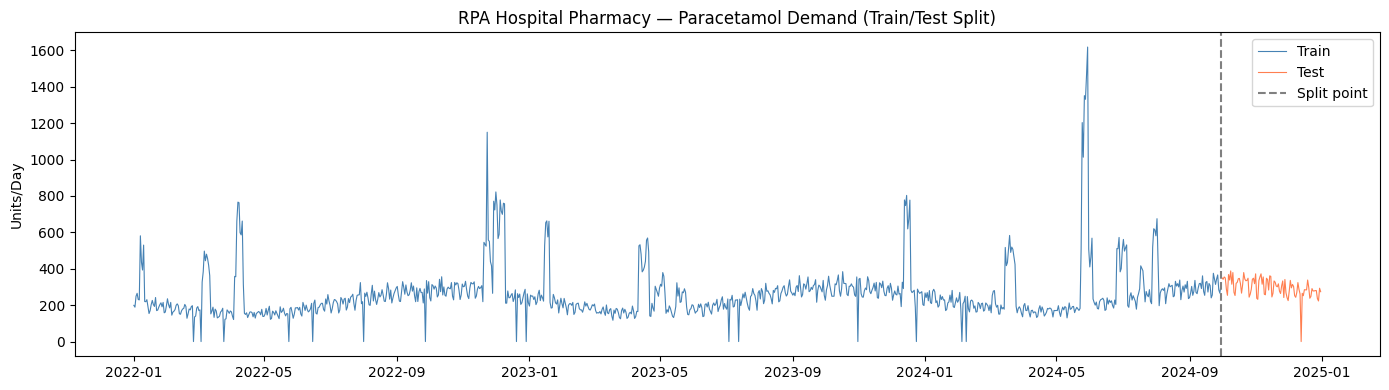

In [2]:
# Extract target series
target = df[
    (df['location'] == 'RPA Hospital Pharmacy') &
    (df['medication'] == 'Paracetamol')
].sort_values('date')[['date', 'demand_units']].reset_index(drop=True)

print(f"Series length : {len(target)} days")
print(f"Date range    : {target['date'].min().date()} → {target['date'].max().date()}")

# Train/test split
split_date = '2024-09-30'
train = target[target['date'] <= split_date].copy()
test  = target[target['date'] >  split_date].copy()

print(f"\nTrain size : {len(train)} days ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Test size  : {len(test)} days  ({test['date'].min().date()} → {test['date'].max().date()})")

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train['date'], train['demand_units'], color='steelblue', linewidth=0.8, label='Train')
ax.plot(test['date'],  test['demand_units'],  color='coral',     linewidth=0.8, label='Test')
ax.axvline(pd.to_datetime(split_date), color='grey', linestyle='--', label='Split point')
ax.set_title('RPA Hospital Pharmacy — Paracetamol Demand (Train/Test Split)')
ax.set_ylabel('Units/Day')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/03_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Evaluation Function

In [3]:
def evaluate(actual, predicted, model_name):
    # Filter out stockout days for MAPE calculation
    mask = actual > 10  # exclude near-zero demand days
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    print(f"{'='*40}")
    print(f"Model : {model_name}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  MAE  : {mae:.2f}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"{'='*40}")
    return {'model': model_name, 'RMSE': round(rmse, 2),
            'MAE': round(mae, 2), 'MAPE': round(mape, 2)}

results = []
print("Evaluation function defined.")

Evaluation function defined.


## 4. Model 0 — Naive Forecast (Simplest Baseline)

The naive forecast assumes tomorrow's demand equals today's demand.  
This is the **minimum benchmark** — any useful model must outperform this.

$$\hat{y}_{t+1} = y_t$$

Model : Naive Forecast (Baseline)
  RMSE : 62.92
  MAE  : 43.23
  MAPE : 13.94%


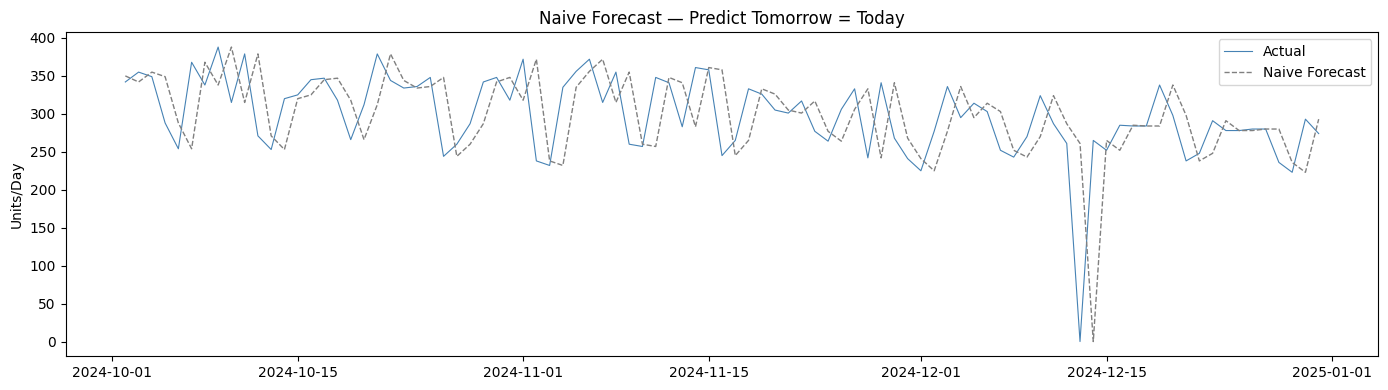

In [4]:
# Naive forecast: next day = current day
naive_pred = test['demand_units'].iloc[:-1].values  # today
naive_actual = test['demand_units'].iloc[1:].values  # tomorrow
naive_dates  = test['date'].iloc[1:].values

# Evaluate
res_naive = evaluate(naive_actual, naive_pred, 'Naive Forecast (Baseline)')
results.append(res_naive)

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(naive_dates, naive_actual, color='steelblue', linewidth=0.8, label='Actual')
ax.plot(naive_dates, naive_pred,   color='grey',      linewidth=1.0,
        linestyle='--', label='Naive Forecast')
ax.set_title('Naive Forecast — Predict Tomorrow = Today')
ax.set_ylabel('Units/Day')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/03_naive_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Model 1 — Prophet (Baseline)

Prophet is a Facebook-developed time series forecasting tool that automatically detects:
- Yearly, weekly, and daily seasonality
- Holiday effects
- Trend changepoints

It serves as our **statistical baseline** — simple to implement but less flexible than ML/DL models.

14:13:26 - cmdstanpy - INFO - Chain [1] start processing
14:13:26 - cmdstanpy - INFO - Chain [1] done processing


Model : Prophet (Baseline)
  RMSE : 244.45
  MAE  : 199.24
  MAPE : 67.97%


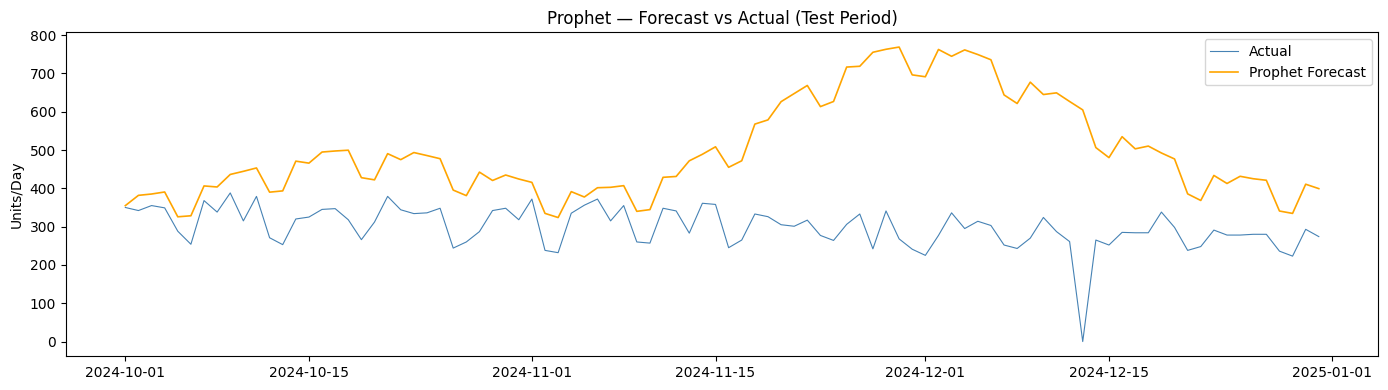

In [5]:
# Prepare Prophet format (requires 'ds' and 'y' columns)
prophet_train = train.rename(columns={'date': 'ds', 'demand_units': 'y'})
prophet_test  = test.rename(columns={'date': 'ds', 'demand_units': 'y'})

# Fit Prophet
prophet_model = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = True,
    daily_seasonality   = False,
    seasonality_mode    = 'multiplicative'
)
prophet_model.fit(prophet_train)

# Predict on test period
future    = prophet_model.make_future_dataframe(periods=len(test))
forecast  = prophet_model.predict(future)
prophet_pred = forecast.tail(len(test))['yhat'].values
prophet_pred = np.maximum(prophet_pred, 0)  # no negative predictions

# Evaluate
res_prophet = evaluate(test['demand_units'].values, prophet_pred, 'Prophet (Baseline)')
results.append(res_prophet)

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test['date'], test['demand_units'], color='steelblue', linewidth=0.8, label='Actual')
ax.plot(test['date'], prophet_pred,         color='orange',    linewidth=1.2, label='Prophet Forecast')
ax.set_title('Prophet — Forecast vs Actual (Test Period)')
ax.set_ylabel('Units/Day')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/03_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model 2 — XGBoost (Mid-Tier)

XGBoost requires manual feature engineering for time series.  
We create **lag features** and **rolling statistics** to give the model temporal context.

### Features engineered:
- Lag 1, 7, 14, 30 days
- Rolling mean and std (7-day, 14-day windows)
- Calendar features: day of week, month, quarter, is_weekend
- Season one-hot encoding

In [6]:
def make_features(data):
    df_feat = data.copy()
    df_feat = df_feat.sort_values('date').reset_index(drop=True)
    y = df_feat['demand_units']

    # Lag features
    for lag in [1, 7, 14, 30]:
        df_feat[f'lag_{lag}'] = y.shift(lag)

    # Rolling statistics
    for window in [7, 14]:
        df_feat[f'rolling_mean_{window}'] = y.shift(1).rolling(window).mean()
        df_feat[f'rolling_std_{window}']  = y.shift(1).rolling(window).std()

    # Calendar features
    df_feat['day_of_week'] = df_feat['date'].dt.dayofweek
    df_feat['month']       = df_feat['date'].dt.month
    df_feat['quarter']     = df_feat['date'].dt.quarter
    df_feat['is_weekend']  = (df_feat['date'].dt.dayofweek >= 5).astype(int)
    df_feat['day_of_year'] = df_feat['date'].dt.dayofyear

    # Season
    def get_season(m):
        if m in [12,1,2]: return 0
        elif m in [3,4,5]: return 1
        elif m in [6,7,8]: return 2
        else: return 3

    df_feat['season'] = df_feat['month'].apply(get_season)

    feature_cols = [c for c in df_feat.columns
                    if c not in ['date', 'demand_units']]
    df_feat = df_feat.dropna()
    return df_feat[feature_cols], df_feat['demand_units'], df_feat['date']


# Build features on full series then split
X_all, y_all, dates_all = make_features(target)
split_idx = dates_all[dates_all <= '2024-09-30'].index[-1]
X_train_xgb = X_all.loc[:split_idx]
y_train_xgb = y_all.loc[:split_idx]
X_test_xgb  = X_all.loc[split_idx+1:]
y_test_xgb  = y_all.loc[split_idx+1:]
dates_test_xgb = dates_all.loc[split_idx+1:]

print(f"XGBoost train features : {X_train_xgb.shape}")
print(f"XGBoost test features  : {X_test_xgb.shape}")
print(f"Features used          : {list(X_train_xgb.columns)}")

XGBoost train features : (974, 14)
XGBoost test features  : (92, 14)
Features used          : ['lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'day_of_week', 'month', 'quarter', 'is_weekend', 'day_of_year', 'season']


Model : XGBoost (Mid-Tier)
  RMSE : 62.49
  MAE  : 41.21
  MAPE : 12.38%


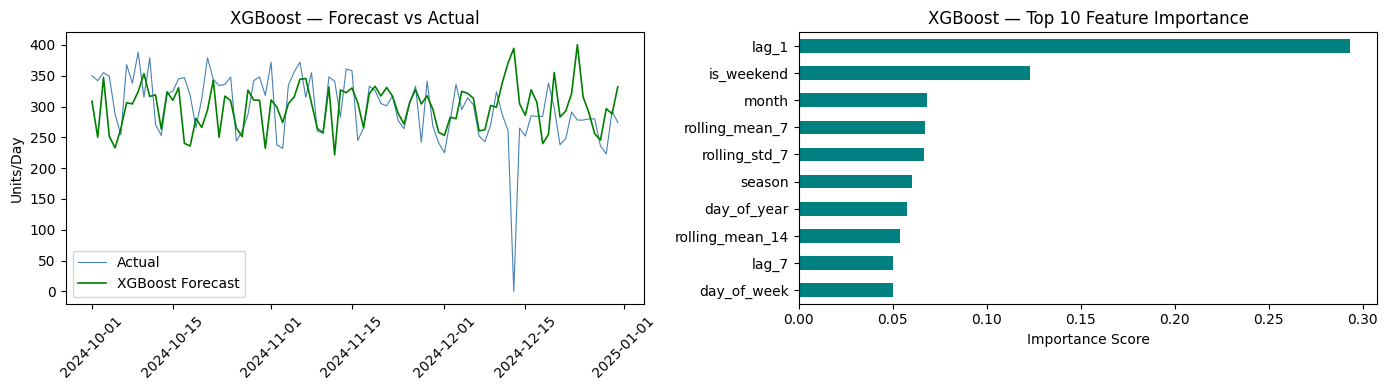

In [7]:
# Train XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    random_state      = 42,
    verbosity         = 0
)
xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set        = [(X_test_xgb, y_test_xgb)],
    verbose         = False
)

xgb_pred = xgb_model.predict(X_test_xgb)
xgb_pred = np.maximum(xgb_pred, 0)

# Evaluate
res_xgb = evaluate(y_test_xgb.values, xgb_pred, 'XGBoost (Mid-Tier)')
results.append(res_xgb)

# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Forecast plot
axes[0].plot(dates_test_xgb.values, y_test_xgb.values, color='steelblue', linewidth=0.8, label='Actual')
axes[0].plot(dates_test_xgb.values, xgb_pred,          color='green',     linewidth=1.2, label='XGBoost Forecast')
axes[0].set_title('XGBoost — Forecast vs Actual')
axes[0].set_ylabel('Units/Day')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Feature importance
feat_imp = pd.Series(xgb_model.feature_importances_, index=X_train_xgb.columns)
feat_imp.sort_values().tail(10).plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('XGBoost — Top 10 Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../reports/03_xgboost_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Model 3 — LSTM (Advanced)

Long Short-Term Memory (LSTM) networks are a type of recurrent neural network (RNN)  
designed to capture **long-range temporal dependencies** in sequential data.

### Architecture:
- Input: 30-day sliding window of demand
- Layer 1: LSTM (64 units) + Dropout(0.2)
- Layer 2: LSTM (32 units) + Dropout(0.2)
- Output: Dense(1) — next day demand

### Why LSTM over Prophet/XGBoost?
LSTM can learn complex non-linear patterns across time without manual feature engineering,  
making it more robust to outbreak anomalies and irregular demand spikes.

In [8]:
# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
series = target['demand_units'].values.reshape(-1, 1)
scaled = scaler.fit_transform(series)

# Create sequences
def create_sequences(data, window=30):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

WINDOW = 30
X_seq, y_seq = create_sequences(scaled, WINDOW)
X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)

# Train/test split (keep same ratio)
train_size = len(train) - WINDOW
X_train_lstm = X_seq[:train_size]
y_train_lstm = y_seq[:train_size]
X_test_lstm  = X_seq[train_size:]
y_test_lstm  = y_seq[train_size:]

print(f"LSTM train shape : {X_train_lstm.shape}")
print(f"LSTM test shape  : {X_test_lstm.shape}")
print(f"Window size      : {WINDOW} days")

LSTM train shape : (974, 30, 1)
LSTM test shape  : (92, 30, 1)
Window size      : 30 days


In [9]:
# Build LSTM model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 0.0100 - val_loss: 0.0050
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0070 - val_loss: 0.0045
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0064 - val_loss: 0.0051
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0062 - val_loss: 0.0047
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0058 - val_loss: 0.0050
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0051 - val_loss: 0.0046
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0054 - val_loss: 0.0039
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0045 - val_loss: 0.0037
Epoch 10/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0044 - val_loss: 0.0037
Epoch 11/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0046 - val_loss: 0.0036
Epoch 12/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

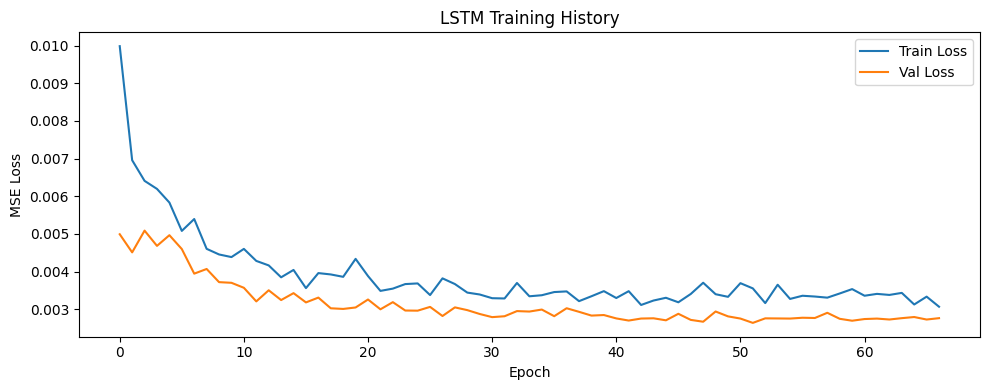

In [10]:
# Train LSTM
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs           = 100,
    batch_size       = 16,
    validation_split = 0.1,
    callbacks        = [early_stop],
    verbose          = 1
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='Train Loss')
ax.plot(history.history['val_loss'], label='Val Loss')
ax.set_title('LSTM Training History')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/03_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step
Model : LSTM (Advanced)
  RMSE : 56.70
  MAE  : 43.93
  MAPE : 13.78%


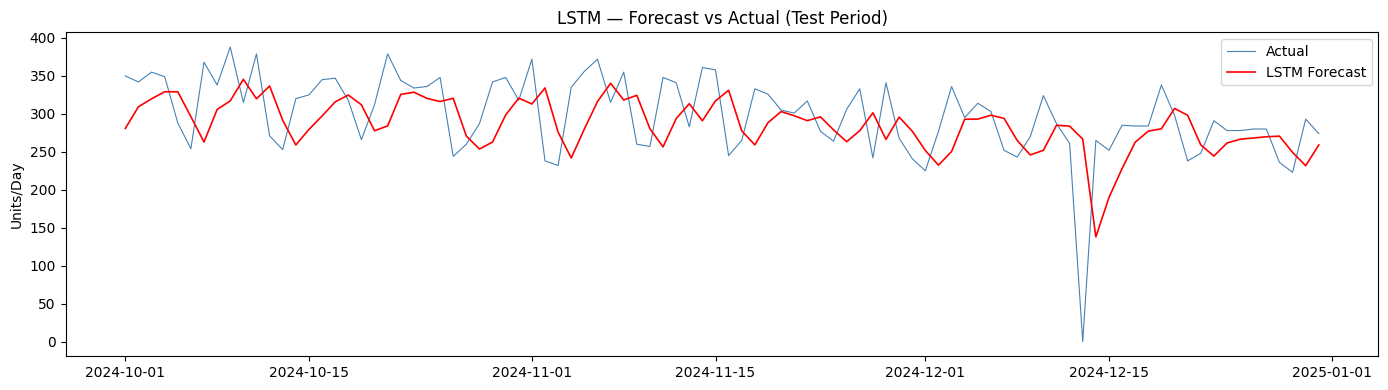

In [11]:
# Predict and inverse transform
lstm_pred_scaled = lstm_model.predict(X_test_lstm)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()
lstm_pred = np.maximum(lstm_pred, 0)

# Align actual values
actual_lstm = scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).flatten()
dates_lstm  = target['date'].values[WINDOW + train_size:]

# Evaluate
res_lstm = evaluate(actual_lstm, lstm_pred, 'LSTM (Advanced)')
results.append(res_lstm)

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates_lstm, actual_lstm, color='steelblue', linewidth=0.8, label='Actual')
ax.plot(dates_lstm, lstm_pred,   color='red',       linewidth=1.2, label='LSTM Forecast')
ax.set_title('LSTM — Forecast vs Actual (Test Period)')
ax.set_ylabel('Units/Day')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/03_lstm_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Comparison

=== Model Comparison ===
                             RMSE     MAE   MAPE
model                                           
Naive Forecast (Baseline)   62.92   43.23  13.94
Prophet (Baseline)         244.45  199.24  67.97
XGBoost (Mid-Tier)          62.49   41.21  12.38
LSTM (Advanced)             56.70   43.93  13.78


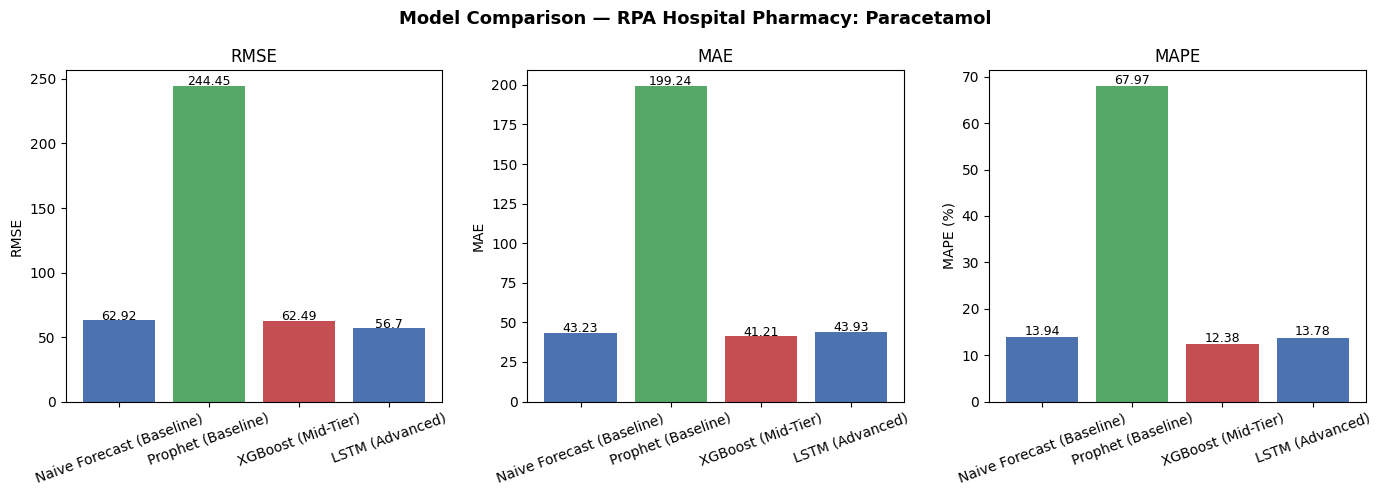


✅ Best model by RMSE: LSTM (Advanced)


In [12]:
results_df = pd.DataFrame(results).set_index('model')
print("=== Model Comparison ===")
print(results_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Model Comparison — RPA Hospital Pharmacy: Paracetamol', fontsize=13, fontweight='bold')

colors = ['#4C72B0', '#55A868', '#C44E52']
models = results_df.index.tolist()

for i, metric in enumerate(['RMSE', 'MAE', 'MAPE']):
    axes[i].bar(models, results_df[metric], color=colors)
    axes[i].set_title(f'{metric}')
    axes[i].set_ylabel(metric if metric != 'MAPE' else 'MAPE (%)')
    axes[i].tick_params(axis='x', rotation=20)
    for j, val in enumerate(results_df[metric]):
        axes[i].text(j, val + 0.5, str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_model = results_df['RMSE'].idxmin()
print(f"\n✅ Best model by RMSE: {best_model}")

## 8. Save LSTM Model & Forecasts

In [13]:
import os

# Save LSTM model
os.makedirs('../src/models', exist_ok=True)
lstm_model.save('../src/models/lstm_paracetamol_rpa.keras')
print("LSTM model saved to: src/models/lstm_paracetamol_rpa.keras")

# Save forecast results
forecast_df = pd.DataFrame({
    'date'      : dates_lstm,
    'actual'    : actual_lstm,
    'lstm_pred' : lstm_pred,
    'prophet_pred': prophet_pred[:len(lstm_pred)] if len(prophet_pred) >= len(lstm_pred) else np.nan,
})
forecast_df.to_csv('../data/processed/forecasts_rpa_paracetamol.csv', index=False)
print("Forecasts saved to: data/processed/forecasts_rpa_paracetamol.csv")

# Save model comparison
results_df.to_csv('../data/processed/model_comparison.csv')
print("Model comparison saved to: data/processed/model_comparison.csv")

LSTM model saved to: src/models/lstm_paracetamol_rpa.keras
Forecasts saved to: data/processed/forecasts_rpa_paracetamol.csv
Model comparison saved to: data/processed/model_comparison.csv
